# Tutorial 08 - Selection methods for generative and predictive models

By the end of this section, students will be able to:

- Give examples of questions that can be answered by generative models and others that can be answered by predictive models.
- Discuss how the research question being asked impacts the statistical modelling procedures.
- Explain how regularized methods, such as lasso and ridge, can be used to estimate a predictive or a generative model.
- Distinguish the selection properties of lasso and ridge penalties.
- Discuss why the model obtained directly from lasso is not the most suitable model for generative modelling and how post-lasso is one way to address this problem.
- Write a computer script to perform lasso/ridge and use it to predict new outcomes.
- Write a computer script to perform post-lasso and use it to estimate a generative model.
- Discuss post-inference problems (e.g., double dipping into the data set) and current practical solutions available to address these (e.g., data-splitting techniques).
- Write a computer script to apply currently available practical solutions to post inference problems.
- Discuss how the research question being asked impacts the communication of the results.

In [1]:
# Loading packages
library(car)
library(tidyverse)
library(tidymodels)
library(glmnet)
library(modeldata)
library(mltools)
source("tests_tutorial_08.R")


Loading required package: carData

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ dplyr::recode() masks car::recode()
✖ purrr::some()   masks car::some()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.2.0 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.2.1     ✔ tune         1.2.1
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.1.0
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────

## Model Selection: Ridge

We have learned that *shrinkage methods* can be used to build predictive models. Some of these methods can also be used to select variables.

In particular, *Ridge method* will not select variables since the estimated coefficients won't be shrunk to zero. However, it can be used when

- there are more predictors than observations
- to address multicollinearity (in fact, that was the primary goal)

In this tutorial, you will use the dataset `concrete` from the `modeldata` package to build a Ridge regression and use it to predict the compressive strength of concrete in a test set.

**Data**: This dataset contains measurements on concrete mixtures, including the amounts of several ingredients and the age of the sample. The data originate from the Concrete Compressive Strength dataset compiled by Yeh (1998) and distributed through the UCI Machine Learning Repository. 

You will use `strength` as the response variable and the remaining 8 continuous variables as predictors. 

> Yeh I., "Modeling of strength of high performance concrete using artificial 
neural networks," *Cement and Concrete Research*, **28**, pp. 1797-1808 (1998)

*Run the code below to create the working dataset called `concrete_sample`*

The response variable `strength` is the measured compressive strength of concrete in megapascals (MPa) for a given mixture under a specific age (days).

The 8 input variables are:

- `cement`: amount of cement in the mixture (kg).
- `slag`: amount of blast furnace slag (kg).
- `fly_ash`: amount of fly ash (kg).
- `water`: amount of water (kg).
- `superplasticizer`: amount of superplasticizer (kg).
- `coarse_agg`: amount of coarse aggregate (kg).
- `fine_agg`: amount of fine aggregate (kg).
- `age`: age of the sample in days (days).

Ridge regression may be particularly useful to analyze the data since mixture components tend be correlated.

In [2]:
# Load and clean the concrete data

data("concrete", package = "modeldata")

concrete_sample <- concrete

names(concrete_sample) <- c(
  "cement", "slag", "fly_ash", "water", "superplasticizer",
  "coarse_agg", "fine_agg", "age", "strength"
)

# Split data into training and test sets
set.seed(123)

training_concrete <- concrete_sample %>%
  sample_frac(0.6)

testing_concrete <- concrete_sample %>%
  setdiff(training_concrete)

# Build matrix and vector required by `glmnet`
# Using `model.matrix()` to get the X matrix; the first column
# corresponds to the intercept and needs to be deleted

concrete_X_train <- model.matrix(object = strength ~ .,
  data = training_concrete)[, -1]
concrete_Y_train <- as.matrix(training_concrete[, "strength"])

concrete_X_test <- model.matrix(object = strength ~ .,
  data = testing_concrete)[, -1]

concrete_Y_test <- as.matrix(testing_concrete[, "strength"])


**Question 1.0**
<br>{points: 1}

Now that we have our training data prepared in `concrete_X_train` and `concrete_Y_train`, we will select the value of $\lambda$ that provides the smallest $\text{MSE}_{\text{test}}$ using cross-validation.

We can do this automatically with function `cv.glmnet()` where `x` is the matrix of input variables and `y` is the vector of responses from the training set that we prepared.

> **Recall**: the method of Ridge regression is defined when `alpha = 0`.

To select `lambda` we will use a **sequence** of values that goes from $\lambda = \exp(-5) = 0.0067$ to $\lambda = \exp(10) = 22026.5$. This is an optional argument. If not specified, `glmnet()` will generate an appropriate sequence for us.

The function `cv.glmnet()` uses cross-validation to compare the average (across folds) test MSE at each of the $\lambda$ values in the grid. 

Assign the function's output as `concrete_cv_lambda_ridge`.

*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*


In [3]:
set.seed(1234) # DO NOT CHANGE!

# concrete_cv_lambda_ridge <- ...(
#   x = ..., y = ...,
#   alpha = ...,
#   lambda = exp(seq(-5, 10, 0.1))
# )

# your code here
concrete_cv_lambda_ridge <- cv.glmnet(
  x = concrete_X_train, y = concrete_Y_train,
  alpha = 0,
  lambda = exp(seq(-5, 10, 0.1))
)


In [4]:
test_1.0()

Test passed 😸
Test passed 🎊
[1] "Success!"


**Question 1.1**
<br>{points: 1}

We can visualize the estimated test MSE at each value of lambda in the sequence by using `concrete_cv_lambda_ridge` and `plot()`.

The resulting plot will indicate the $\text{MSE}_{\text{test}}$ on the $y$-axis (error bars show the variation of the test error in the different folds) along with the range of $\lambda$ on the bottom $x$-axis on the natural log-scale.

> **Recall**: Ridge regression never shrinks estimators to zero, so the top axis will continue to show all 8 predictors in the model.

*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*


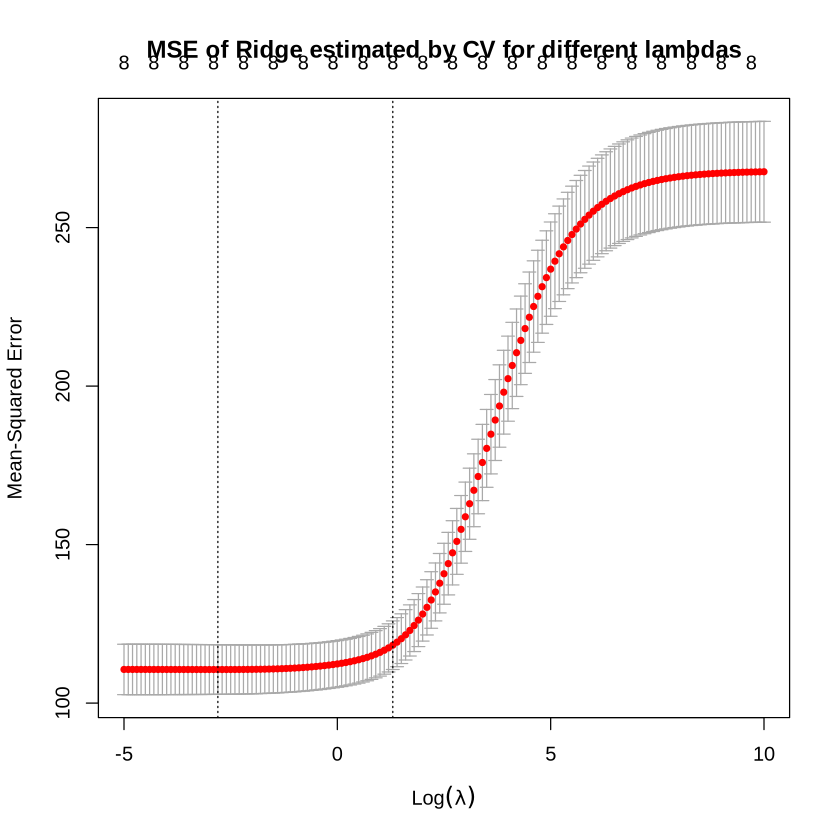

In [5]:
# plot_data <- ...

# your code here
plot_data <- concrete_cv_lambda_ridge

plot(plot_data, main = "MSE of Ridge estimated by CV for different lambdas")


In [6]:
test_1.1()

Test passed 🎊
Test passed 😸
[1] "Success!"


**Question 1.2**
<br>{points: 1}

The plot in **Question 1.1** also shows two vertical dotted lines. *Given an `object` coming from `cv.glmnet()`*, these lines correspond to two values of $\lambda$:

- $\hat{\lambda}_{\text{min}}$ which minimizes MSE. It can be obtained with `object$lambda.min`.

- $\hat{\lambda}_{\text{1SE}}$ for which the MSE is within one standard error of the minimum. It can be obtained with `object$lambda.1se`.

Using `concrete_cv_lambda_ridge`, obtain $\hat{\lambda}_{\text{min}}$ and save it as `concrete_lambda_min_MSE_ridge`.

*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*


In [13]:
# concrete_lambda_min_MSE_ridge <- round(..., 4)

# your code here
concrete_lambda_min_MSE_ridge <- round(concrete_cv_lambda_ridge$lambda.min, 4)

concrete_lambda_min_MSE_ridge


[1] 0.0608

In [14]:
test_1.2()

Test passed 🥇
Test passed 🌈
Test passed 🎊
[1] "Success!"


**Question 1.3**
<br>{points: 1}

Once we have selected a value of $\lambda$, we can extract the estimated Ridge regression at that level of penalization. Store the estimated coefficients in `concrete_ridge_min_coef`.

*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*


In [17]:
set.seed(1234) # DO NOT CHANGE!

# concrete_ridge_min_coef <- ...(..., s = ...)

# your code here
concrete_ridge_min_coef <- coef(concrete_cv_lambda_ridge, s = "lambda.min")

concrete_ridge_min_coef

9 x 1 sparse Matrix of class "dgCMatrix"
                           s1
(Intercept)      -20.06296178
cement             0.10693583
slag               0.09236391
fly_ash            0.06131723
water             -0.11610515
superplasticizer   0.62228510
coarse_agg         0.01910823
fine_agg           0.01237350
age                0.11603206

In [18]:
test_1.3()

Test passed 🌈
Test passed 🥳
[1] "Success!"


**Question 1.4**
<br>{points: 1}

Let's compare the estimated regression coefficients of `concrete_ridge_min_coef` with those of `concrete_full_OLS`. Both models are estimating using the training data only.

Create a data frame called `concrete_coefs` with two columns:

- `Full_OLS`: The estimated coefficients from `concrete_full_OLS` obtained via function `coef()`.
- `Ridge_min`: The estimated coefficients in `concrete_ridge_min_coef`. Recall this is the estimated ridge regression with $\hat{\lambda}_{\text{min}}$.

*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*

In [19]:
# concrete_full_OLS <- ...

# concrete_coefs <- cbind(
#   Full_OLS = ...(...),
#   Ridge_min = as.vector(...)) %>%
#       round(4) %>% as.data.frame()

# your code here
concrete_full_OLS <- lm(strength ~ ., data = training_concrete)

concrete_coefs <- cbind(
  Full_OLS = coef(concrete_full_OLS),
  Ridge_min = as.vector(concrete_ridge_min_coef)) %>%
      round(4) %>% as.data.frame()

concrete_coefs


,Full_OLS,Ridge_min
,<dbl>,<dbl>
(Intercept),-37.8254,-20.0630
cement,0.1133,0.1069
slag,0.0997,0.0924
fly_ash,0.0703,0.0613
water,-0.0951,-0.1161
superplasticizer,0.6212,0.6223
coarse_agg,0.0248,0.0191
fine_agg,0.0195,0.0124
age,0.1168,0.1160


In [20]:
test_1.4()

Test passed 🎉
Test passed 🥇
Test passed 🌈
Test passed 🎊
Test passed 😀
Test passed 🥇
[1] "Success!"


**Question 1.5**
<br>{points: 1}

Write code following the steps outlined below.

- Using `predict()` and `concrete_full_OLS`, obtain the out-of-sample predicted `strength` values for the mixtures in `testing_concrete`. Store them in a variable called `concrete_test_pred_full_OLS`.

Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.


In [23]:
# concrete_test_pred_full_OLS <- ...

# your code here
concrete_test_pred_full_OLS <- predict(concrete_full_OLS, newdata = testing_concrete)

head(concrete_test_pred_full_OLS)


1        2        3        4        5        6 
51.79987 52.17237 58.64279 69.73611 70.38209 21.48954

In [24]:
test_1.5()

Test passed 🌈
Test passed 🥳
[1] "Success!"


**Question 1.6**
<br>{points: 1}

We will now compute the **Mean Squared Error (MSE)** on the test set to evaluate the predictive model (the smaller the metric, the better the model):

> **Heads up:** a related measure commonly used is the **Root Mean Squared Error (RMSE) = $\sqrt{\text{MSE}}$**, which is the standard deviation of the prediction errors $y_i - \hat{y}_i$. This metric has the same units as the response.

Use the function `rmse()` from the `mltools` package to compute the $\text{RMSE}_{\text{test}}$ of the predicted concrete strengths in `concrete_test_pred_full_OLS`.

Store the computed RMSE metric in a tibble called `concrete_test_RMSEs` with two columns:

- `Model`: The regression model from which we obtain the prediction accuracy.
- `RMSE`: The corresponding $\text{RMSE}_{\text{test}}$.

*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*

In [25]:
# concrete_test_RMSEs <- tibble(
#   Model = "OLS Full Regression",
#   RMSE = ...(
#     preds = ...,
#     actuals = ...
#   )
# )

# your code here
concrete_test_RMSEs <- tibble(
  Model = "OLS Full Regression",
  RMSE = rmse(
    preds = concrete_test_pred_full_OLS,
    actuals = testing_concrete$strength
  )
)

concrete_test_RMSEs

Model,RMSE
<chr>,<dbl>
OLS Full Regression,10.66067


In [26]:
test_1.6()

Test passed 🎊
Test passed 🎉
Test passed 🥳
Test passed 🎉
Test passed 🎊
[1] "Success!"


**Question 1.7**
<br>{points: 1}

Use `concrete_cv_lambda_ridge` and the level of penalization that minimizes the CV-MSE to predict the concrete strength in the test set `testing_concrete`, and call the resulting object `concrete_test_pred_ridge_min`.

> **Hint:** Use function `predict()` with the argument `newx` to specify the test set.

*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*


In [27]:
# concrete_test_pred_ridge_min <- predict(...,
#   newx = ..., ...)

# your code here
concrete_test_pred_ridge_min <- predict(concrete_cv_lambda_ridge,
  newx = concrete_X_test, s="lambda.min")


In [28]:
test_1.7()

Test passed 🎉
Test passed 🌈
[1] "Success!"


**Question 1.8**
<br>{points: 1}

Use the function `rmse()` to compute $\text{RMSE}_{\text{test}}$ using the predicted values stored in `concrete_test_pred_ridge_min`.

Add this metric as an additional row in the tibble `concrete_test_RMSEs`. Use `"Ridge Regression with minimum MSE"` in column `Model` and the corresponding value for $\text{RMSE}_{\text{test}}$ in column `RMSE`.

**NOTE**: the code below binds rows into `concrete_test_RMSEs`. Do not re-run this cell or restart the kernel if needed. Otherwise, this object will have extra repeated rows.

*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*


In [29]:
# concrete_test_RMSEs <- rbind(
#   concrete_test_RMSEs,
#   tibble(
#     Model = "Ridge Regression with minimum MSE",
#     RMSE = ...(
#       ...,
#       ...
#     )
#   )
# )

# your code here
concrete_test_RMSEs <- rbind(
  concrete_test_RMSEs,
  tibble(
    Model = "Ridge Regression with minimum MSE",
    RMSE = rmse(
        preds = concrete_test_pred_ridge_min,
        actuals = concrete_Y_test
    )
  )
)

concrete_test_RMSEs


Model,RMSE
<chr>,<dbl>
OLS Full Regression,10.66067
Ridge Regression with minimum MSE,10.67652


In [30]:
test_1.8()

Test passed 🎉
Test passed 🎉
Test passed 🎉
Test passed 🌈
Test passed 🌈
[1] "Success!"


**Question 1.9**
<br>{points: 1}

Based on your results in `concrete_test_RMSEs`, which model shows the best prediction? Was this an expected result? Justify your answer.


> *Based on the results in `concrete_test_RMSEs`, the OLS model shows the best prediction accuracy since its RMSE is slightly lower than the Ridge Regression model. The OLS model exhibited an RMSE value of `10.66` whereas the Ridge Regression model exhibited an RMSE value of `10.68`.*
>
> This was an expected result since ridge aims to decrease the variance by increasing the bias. When there are many predictors compared to a small number of observations, this will often increase the overall model accuracy by tuning out additional noise in the data. However, in this case there are only 8 predictors and hundreds of observations in the training data which means that the OLS model is likely not overfitting the model. In other words, regularization is not really necessary given the available data since there is minimal risk of overfitting the model when using OLS. Since OLS is able to pick up more patterns in the data, it makes sense why it has a lower RMSE compared to the Ridge Regression model.

## Model Selection For Inference

In the second part of this tutorial, you will select a generative model using a real data set and use it for inference. 

**Recall** the [Ames `Housing` dataset](https://www.kaggle.com/c/home-data-for-ml-course/) you worked on Worksheet 08. Let's refresh our memory: it was compiled by Dean De Cock, it has 79 input variables on different characteristics of residential houses in Ames, Iowa, USA that can be used to predict the property's final price, `SalePrice`. As in worksheet_08, we will focus our attention on 21 numerical input variables:

- `LotFrontage`: Linear $\text{ft}$ of street connected to the house.
- `LotArea`: Lot size in $\text{ft}^2$.
- `MasVnrArea`: Masonry veneer area in $\text{ft}^2$.
- `TotalBsmtSF`: Total $\text{ft}^2$ of basement area.
- `GrLivArea`: Above grade (ground) living area in $\text{ft}^2$.
- `BsmtFullBath`: Number of full bathrooms in basement.
- `BsmtHalfBath`: Number of half bathrooms in basement.
- `FullBath`: Number of full bathrooms above grade.
- `HalfBath`: Number of half bathroom above grade.
- `BedroomAbvGr`: Number of bedrooms above grade (it does not include basement bedrooms).
- `KitchenAbvGr`: Number of kitchens above grade.
- `Fireplaces`: Number of fireplaces.
- `GarageArea`: Garage's area in $\text{ft}^2$.
- `WoodDeckSF`: Wood deck area in $\text{ft}^2$.
- `OpenPorchSF`: Open porch area in $\text{ft}^2$.
- `EnclosedPorch`: Enclosed porch area in $\text{ft}^2$.
- `ScreenPorch`: Screen porch area in $\text{ft}^2$.

Let's start by loading the data set. 

In [32]:
## Load the housing data set
housing_raw <- read_csv("data/Housing.csv", col_types = cols())

# Use `YearBuilt` and `YrSold` to create a variable `ageSold`
housing_raw$ageSold <- housing_raw$YrSold - housing_raw$YearBuilt


# Select subset of input variables
housing_raw <- 
  housing_raw %>%
  select(LotFrontage, LotArea, MasVnrArea, TotalBsmtSF, 
    GrLivArea, BsmtFullBath, BsmtHalfBath, FullBath, HalfBath, BedroomAbvGr, KitchenAbvGr, Fireplaces,
    GarageArea, WoodDeckSF, OpenPorchSF, EnclosedPorch, ScreenPorch, PoolArea, ageSold, SalePrice
  )

# Remove those rows containing `NA`s and some outliers
housing_raw <- 
    drop_na(housing_raw)  %>% 
    filter(LotArea < 20000)

str(housing_raw)

tibble [1,162 × 20] (S3: tbl_df/tbl/data.frame)
 $ LotFrontage  : num [1:1162] 65 80 68 60 84 85 75 51 50 70 ...
 $ LotArea      : num [1:1162] 8450 9600 11250 9550 14260 ...
 $ MasVnrArea   : num [1:1162] 196 0 162 0 350 0 186 0 0 0 ...
 $ TotalBsmtSF  : num [1:1162] 856 1262 920 756 1145 ...
 $ GrLivArea    : num [1:1162] 1710 1262 1786 1717 2198 ...
 $ BsmtFullBath : num [1:1162] 1 0 1 1 1 1 1 0 1 1 ...
 $ BsmtHalfBath : num [1:1162] 0 1 0 0 0 0 0 0 0 0 ...
 $ FullBath     : num [1:1162] 2 2 2 1 2 1 2 2 1 1 ...
 $ HalfBath     : num [1:1162] 1 0 1 0 1 1 0 0 0 0 ...
 $ BedroomAbvGr : num [1:1162] 3 3 3 3 4 1 3 2 2 3 ...
 $ KitchenAbvGr : num [1:1162] 1 1 1 1 1 1 1 2 2 1 ...
 $ Fireplaces   : num [1:1162] 0 1 1 1 1 0 1 2 2 0 ...
 $ GarageArea   : num [1:1162] 548 460 608 642 836 480 636 468 205 384 ...
 $ WoodDeckSF   : num [1:1162] 0 298 0 0 192 40 255 90 0 0 ...
 $ OpenPorchSF  : num [1:1162] 61 0 42 35 84 30 57 0 4 0 ...
 $ EnclosedPorch: num [1:1162] 0 0 0 272 0 0 0 205 0 0 ...
 $

Our objective in this tutorial is to obtain a model for inference. We want to study how the properties' values are affected by the different properties' attributes. We want to be able to:

1. Interpret the parameters of the model;
2. Identify relevant attributes (covariates); 
3. Have a measure of uncertainty of our estimates.

**Question 2.0** 
<br> {points: 1}

Since we do not know which variables are important/relevant, we will need to conduct a variable selection technique. Let's start by splitting the data set into two sets: (1) the first part, with 60% of the rows, will be used to select a model; and (2) the second part, will be for inference. 

> Note that the partition is similar to the training-test one used in prediction problems.

Your job is to randomly select 60% of the rows and store them in an object called `housing_selection`. Store the remaining rows in an object called `housing_inference`.

The `housing_inference` object is golden! It should not be touched before we select the variables. No peeking!!  

In [34]:
set.seed(20211118) # Do not change this

# Housing_split <- ...(..., prop = ..., strata = SalePrice)
# housing_selection <- training(Housing_split)
# housing_inference <- testing(Housing_split)

# your code here
Housing_split <- initial_split(housing_raw, prop = 0.60, strata = SalePrice)
housing_selection <- training(Housing_split)
housing_inference <- testing(Housing_split)

head(housing_selection)

LotFrontage,LotArea,MasVnrArea,TotalBsmtSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,Fireplaces,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,PoolArea,ageSold,SalePrice
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
50,7420,0,991,1077,1,0,1,0,2,2,2,205,0,4,0,0,0,69,118000
72,10791,0,0,1296,0,0,2,0,2,2,0,516,0,0,0,0,0,39,90000
60,6324,0,520,520,0,0,1,0,1,1,0,240,49,0,87,0,0,81,68500
65,6040,0,0,1152,0,0,2,0,2,2,0,0,0,0,0,0,0,53,82000
33,4456,0,736,1452,0,0,2,0,2,3,0,0,0,0,102,0,0,89,113000
52,6240,0,816,1176,0,0,1,0,3,1,1,528,112,0,0,0,0,72,114500


In [35]:
test_2.0()

Test passed 🥇
Test passed 🌈
Test passed 😸
Test passed 😀
Test passed 😸
Test passed 🌈
Test passed 🎊
Test passed 🥳
Test passed 🌈
Test passed 🥳
[1] "Success!"


**Question 2.1** 
<br> {points: 1}

As we discussed in the worksheet, there are many possible approaches for model selection. Let's focus on Lasso. Run Lasso on the `housing_selection` tibble and find the value `lambda` that provides the lowest Cross-validation MSE. (See `cv.glmnet` function.)

_Save the result in an object named `lasso_model`._

In [36]:
set.seed(20211118) # do not change this

# lasso_model <-
#     cv.glmnet(x = ... %>% ...(-...)%>% as.matrix(), 
#               y = ..., 
#               alpha = ...)

# your code here
lasso_model <-
    cv.glmnet(x = housing_selection %>% select(-SalePrice)%>% as.matrix(), 
              y = housing_selection$SalePrice, 
              alpha = 1)

lasso_model


Call:  cv.glmnet(x = housing_selection %>% select(-SalePrice) %>% as.matrix(),      y = housing_selection$SalePrice, alpha = 1) 

Measure: Mean-Squared Error 

    Lambda Index   Measure        SE Nonzero
min   1242    42 1.189e+09 142109291      16
1se   5012    27 1.325e+09 190839032      11

In [37]:
test_2.1()

Test passed 🎊
Test passed 🎊
Test passed 🎉
Test passed 🎊
[1] "Success!"


**Question 2.2** 
<br> {points: 1}

Write a code to extract the coefficients of the best lasso model found in the `lasso_model`. By best, we mean the one with the smallest MSE. 

_Save the result in an object named `beta_lasso`._

In [38]:
set.seed(20211118) # do not change this


# your code here
beta_lasso <- coef(lasso_model, s = "lambda.min")

beta_lasso

20 x 1 sparse Matrix of class "dgCMatrix"
                         s1
(Intercept)    41788.164089
LotFrontage       51.984257
LotArea            1.638466
MasVnrArea        16.398239
TotalBsmtSF       39.685572
GrLivArea         82.377540
BsmtFullBath    9185.241114
BsmtHalfBath    1861.607340
FullBath        3253.628598
HalfBath           .       
BedroomAbvGr  -12225.406290
KitchenAbvGr  -25858.677209
Fireplaces      6851.586953
GarageArea        37.946861
WoodDeckSF        27.133165
OpenPorchSF       20.182375
EnclosedPorch      .       
ScreenPorch        .       
PoolArea          69.258936
ageSold         -526.629443

In [39]:
test_2.2()

Test passed 😸
Test passed 🥇
[1] "Success!"


**Question 2.3** 
<br> {points: 1}

Extract the name of the covariates selected by Lasso in an object named `lasso_selected_covariates`.  

In [41]:
#lasso_selected_covariates <- as_tibble(
        # as.matrix(...),
        # rownames='covariate') %>%
        # filter(covariate != '(Intercept)' & abs(s1) !=0) %>% 
        # pull(...)

# your code here
lasso_selected_covariates <- as_tibble(
        as.matrix(beta_lasso),
        rownames='covariate') %>%
        filter(covariate != '(Intercept)' & abs(s1) !=0) %>% 
        pull(covariate)

lasso_selected_covariates

[1] "LotFrontage"  "LotArea"      "MasVnrArea"   "TotalBsmtSF"  "GrLivArea"   
 [6] "BsmtFullBath" "BsmtHalfBath" "FullBath"     "BedroomAbvGr" "KitchenAbvGr"
[11] "Fireplaces"   "GarageArea"   "WoodDeckSF"   "OpenPorchSF"  "PoolArea"    
[16] "ageSold"

In [42]:
test_2.3()

Test passed 😀
Test passed 🥳
[1] "Success!"


**Question 2.4** 
<br> {points: 1}

In **Question 1.4** of this tutorial you extracted the estimated coefficients obtained using Ridge. In **Question 2.3**, you identified the variables selected by LASSO. 

**What is a main difference between these two methods in terms of variable selection?** Comment on the numbers of variables selected in relation to the variables available in the dataset.

> *The main difference between these two methods in terms of variable selection is that ridge will shrink coefficients as a form of regularization, however, it will not shrink the values all the way to 0. Therefore, using ridge will not reduce the number of predictors in the model. However, LASSO can shrink coefficients to 0. This means that LASSO is capable of leaving coefficients out of the model entirely (i.e. reducing the number of predictors in the model).*
>
> *In 1.4, Ridge shrunk coefficients in an effort to reduce variance, however, it kept all 8 predictors (as expected). However in question 2.3 when LASSO was used for regularization, it shows 16 selected predictors out of the available 19. Question 2.2 shows that `HalfBath`, `EnclosedPorch`, and `ScreenPorch` were all selected to be excluded in the model. LASSO shrunk the coefficients and reduced the overall size of the model, whereas ridge only shrunk the coefficients (i.e. while the overall size of the model was not altered).*

**Question 2.5** 
<br> {points: 1}

We expect that LASSO would remove highly correlated variables. However, LASSO can still fit a linear model on data sets with high levels of multicollinearity. Unfortunately, ordinary least squares cannot. To be on the safe side, let's check the variance inflator factor of the variables selected by LASSO. 

_Save the output in an object named `lasso_variables_vif`._

In [47]:
#lasso_variables_vif <- 
#    vif(...)

# your code here
lasso_variables_vif <- 
   vif(lm(SalePrice ~ . -HalfBath -EnclosedPorch -ScreenPorch, data = housing_selection))

lasso_variables_vif

LotFrontage      LotArea   MasVnrArea  TotalBsmtSF    GrLivArea BsmtFullBath 
    2.002766     2.142484     1.291460     1.774998     3.385926     1.202616 
BsmtHalfBath     FullBath BedroomAbvGr KitchenAbvGr   Fireplaces   GarageArea 
    1.054325     2.538401     1.846096     1.212782     1.396206     1.821433 
  WoodDeckSF  OpenPorchSF     PoolArea      ageSold 
    1.196053     1.187022     1.060102     2.214560

In [48]:
test_2.5()

Test passed 🌈
Test passed 🥳
[1] "Success!"


**Question 2.6**
<br>{points: 1}

True or false?

The `lasso_variables_vif` does not indicate a very concerning presence of multicollinearity. 

_Assign your answer to an object called `answer2.6`. Your answer should be either "true" or "false", surrounded by quotes._

In [49]:
# answer2.6 <- ...

# your code here
answer2.6 <- "true"

In [50]:
test_2.6()

Test passed 😸
Test passed 🥳
Test passed 🥳
[1] "Success!"


**Question 2.7** 
<br> {points: 1}

Finally, let's use the covariates selected by lasso and stored in `lasso_selected_covariates` to fit a linear model using ordinary least squares.

_Save the output in an object named `inference_model`._

In [53]:
# your code here
inference_model <- lm(SalePrice ~ . -HalfBath -EnclosedPorch -ScreenPorch, data = housing_inference)

summary(inference_model)


Call:
lm(formula = SalePrice ~ . - HalfBath - EnclosedPorch - ScreenPorch, 
    data = housing_inference)

Residuals:
    Min      1Q  Median      3Q     Max 
-116117  -17245    -957   15177  215069 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)   6.551e+04  1.071e+04   6.120 2.04e-09 ***
LotFrontage   6.383e+01  1.041e+02   0.613  0.54005    
LotArea       1.707e+00  6.853e-01   2.491  0.01308 *  
MasVnrArea    5.068e+01  1.030e+01   4.920 1.22e-06 ***
TotalBsmtSF   3.452e+01  4.734e+00   7.293 1.38e-12 ***
GrLivArea     7.460e+01  5.647e+00  13.211  < 2e-16 ***
BsmtFullBath  9.642e+03  3.248e+03   2.968  0.00315 ** 
BsmtHalfBath -8.888e+03  7.117e+03  -1.249  0.21240    
FullBath      7.382e+03  4.214e+03   1.752  0.08051 .  
BedroomAbvGr -1.496e+04  2.403e+03  -6.224 1.11e-09 ***
KitchenAbvGr -3.739e+04  6.986e+03  -5.352 1.39e-07 ***
Fireplaces    5.919e+03  2.969e+03   1.994  0.04681 *  
GarageArea    4.259e+01  9.370e+00   4.545 7.06e-06 ***


In [54]:
test_2.7()

Test passed 🥇
Test passed 😸
[1] "Success!"


**Question 2.8** 
<br> {points: 1}

The model stored in `inference_model` has shown 5 non-significant variables at 5% significance level. Should we remove these variables and re-fit the model with them? Briefly explain why or why not. 

> *We should not remove these variables and re-fit the model with them. The training data is the data that's used to make the variable selection; the testing data is used solely to fit the model using the previously determined predictors, and make inferences. If we were to remove the variables and re-fit the model based on observations from fitting on the testing data, we would essentially be using the testing data for variable selection then make inferences based on this model. This would be using the same set of data for multiple purposes; this is known as the post-inference problem which is "using the same data to find variables and fit the model". By keeping the "non-influential" predictors in the model, it honours the golden rule and keeps training and testing separate.*